# Visualize a Random AlphaEarth Band

This notebook loads the AlphaEarth mosaic GeoTIFF and displays a randomly selected band as a grayscale image.

In [1]:
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt

def find_repo_root(start: Path) -> Path | None:
    for candidate in [start] + list(start.parents):
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return None

repo_root = find_repo_root(Path.cwd())
if repo_root is None:
    raise FileNotFoundError("Could not locate repo root containing data/ and notebooks/.")

mosaic_path = repo_root / "data/interim/bd_coastal_alphaearth_2024_mosaic.tif"

if not mosaic_path.exists():
    candidates = sorted((repo_root / "data/interim").glob("*alphaearth*.tif"))
    message = [
        f"Mosaic file not found at {mosaic_path}.",
        "Run scripts/gee/mosaic_alphaearth_tiles.py or update mosaic_path.",
    ]
    if candidates:
        message.append("Found these candidates under data/interim:\n  - " + "\n  - ".join(str(p) for p in candidates))
    raise FileNotFoundError("\n".join(message))

mosaic_path


PosixPath('/mnt/AAzizSSD/BDlulcModel/data/interim/bd_coastal_alphaearth_2024_mosaic.tif')

In [2]:
rng = np.random.default_rng()

with rasterio.open(mosaic_path) as src:
    if src.count < 1:
        raise ValueError("No bands found in the mosaic file.")

    band_count = src.count
    band_index = int(rng.integers(1, band_count + 1))

    # Downsample aggressively for fast visualization.
    max_dim = 600
    overviews = src.overviews(band_index)
    decim = 1
    if overviews:
        for factor in sorted(overviews):
            if max(src.width / factor, src.height / factor) <= max_dim:
                decim = factor
    scale = max(src.width / max_dim, src.height / max_dim, 1)
    out_width = max(1, int(src.width / max(scale, decim)))
    out_height = max(1, int(src.height / max(scale, decim)))

    band = src.read(
        band_index,
        out_shape=(out_height, out_width),
        resampling=rasterio.enums.Resampling.nearest,
    ).astype("float32")

band.shape, band_index, band_count


((485, 600), 30, 64)

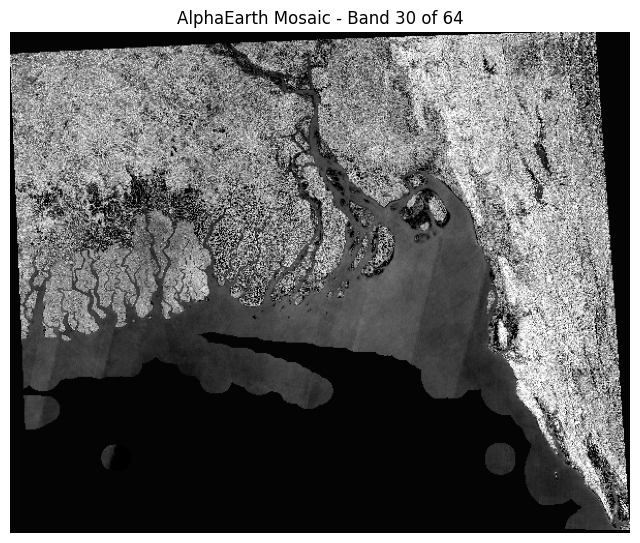

In [3]:
vmin, vmax = np.nanpercentile(band, [2, 98])

plt.figure(figsize=(8, 8))
plt.imshow(band, cmap="gray", vmin=vmin, vmax=vmax)
plt.title(f"AlphaEarth Mosaic - Band {band_index} of {band_count}")
plt.axis("off")
plt.show()
